In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Download and unzip the dataset
!curl -O https://archive.ics.uci.edu/static/public/53/iris.zip
!unzip iris.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3738    0  3738    0     0  31358      0 --:--:-- --:--:-- --:--:-- 31411
Archive:  iris.zip
  inflating: Index                   
  inflating: bezdekIris.data         
  inflating: iris.data               
  inflating: iris.names              


In [ ]:
# Read the dataset using open, readlines, and close
with open("iris.data", "r") as f:
    iris_lines = f.readlines()

print(iris_lines)

['5.1,3.5,1.4,0.2,Iris-setosa\n', '4.9,3.0,1.4,0.2,Iris-setosa\n', '4.7,3.2,1.3,0.2,Iris-setosa\n', '4.6,3.1,1.5,0.2,Iris-setosa\n', '5.0,3.6,1.4,0.2,Iris-setosa\n', '5.4,3.9,1.7,0.4,Iris-setosa\n', '4.6,3.4,1.4,0.3,Iris-setosa\n', '5.0,3.4,1.5,0.2,Iris-setosa\n', '4.4,2.9,1.4,0.2,Iris-setosa\n', '4.9,3.1,1.5,0.1,Iris-setosa\n', '5.4,3.7,1.5,0.2,Iris-setosa\n', '4.8,3.4,1.6,0.2,Iris-setosa\n', '4.8,3.0,1.4,0.1,Iris-setosa\n', '4.3,3.0,1.1,0.1,Iris-setosa\n', '5.8,4.0,1.2,0.2,Iris-setosa\n', '5.7,4.4,1.5,0.4,Iris-setosa\n', '5.4,3.9,1.3,0.4,Iris-setosa\n', '5.1,3.5,1.4,0.3,Iris-setosa\n', '5.7,3.8,1.7,0.3,Iris-setosa\n', '5.1,3.8,1.5,0.3,Iris-setosa\n', '5.4,3.4,1.7,0.2,Iris-setosa\n', '5.1,3.7,1.5,0.4,Iris-setosa\n', '4.6,3.6,1.0,0.2,Iris-setosa\n', '5.1,3.3,1.7,0.5,Iris-setosa\n', '4.8,3.4,1.9,0.2,Iris-setosa\n', '5.0,3.0,1.6,0.2,Iris-setosa\n', '5.0,3.4,1.6,0.4,Iris-setosa\n', '5.2,3.5,1.5,0.2,Iris-setosa\n', '5.2,3.4,1.4,0.2,Iris-setosa\n', '4.7,3.2,1.6,0.2,Iris-setosa\n', '4.8,3.1,

In [6]:
# Remove the last empty line
iris_lines.pop(-1)

'\n'

In [11]:
# Split lines into columns
split_lines = [line.split(',') for line in iris_lines]
split_lines[:5]  # Display the first 5 rows

[['5.1', '3.5', '1.4', '0.2', 'Iris-setosa\n'],
 ['4.9', '3.0', '1.4', '0.2', 'Iris-setosa\n'],
 ['4.7', '3.2', '1.3', '0.2', 'Iris-setosa\n'],
 ['4.6', '3.1', '1.5', '0.2', 'Iris-setosa\n'],
 ['5.0', '3.6', '1.4', '0.2', 'Iris-setosa\n']]

In [13]:
# Create a DataFrame from the split lines
iris_df = pd.DataFrame(split_lines, columns=["sepal length", "sepal width", "petal length", "petal width", 'class'])
iris_df = iris_df.apply(pd.to_numeric, errors='ignore')
iris_df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa\n
1,4.9,3.0,1.4,0.2,Iris-setosa\n
2,4.7,3.2,1.3,0.2,Iris-setosa\n
3,4.6,3.1,1.5,0.2,Iris-setosa\n
4,5.0,3.6,1.4,0.2,Iris-setosa\n


In [4]:
# Alternatively, pandas has a function to read CSV files directly
iris_df = pd.read_csv("iris.data", header=None, names=["sepal length", "sepal width", "petal length", "petal width", 'class'])
iris_df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Only keeping numeric features
iris_df = iris_df.drop(columns=['class'])
iris_df.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
# Calculate standard deviation for sepal length
sepal_length = iris_df['sepal length']
std_sepal_length = sepal_length.std()
print(f"Standard Deviation of Sepal Length: {std_sepal_length}")

Standard Deviation of Sepal Length: 0.8280661279778629


In [7]:
# Calculate maximum values for each feature
max_vals = iris_df.max()
print(max_vals)

sepal length    7.9
sepal width     4.4
petal length    6.9
petal width     2.5
dtype: float64


In [8]:
# Access maximum values for sepal length
print(f"Maximum Sepal Length: {max_vals['sepal length']}")

Maximum Sepal Length: 7.9


In [9]:
# Scale the feature values
scaled_df = iris_df / max_vals
scaled_df.head()

,sepal length,sepal width,petal length,petal width
0,0.645570,0.795455,0.202899,0.08
1,0.620253,0.681818,0.202899,0.08
2,0.594937,0.727273,0.188406,0.08
3,0.582278,0.704545,0.217391,0.08
4,0.632911,0.818182,0.202899,0.08


In [ ]:
# Save the max val to a text file
max_val_strs = [str(val) for val in max_vals]
max_val_result = ", ".join(max_val_strs)
with open("max_vals.txt", 'w') as f:
    f.write(max_val_result)

In [ ]:
# Save the scaled features to a text file
with open("scaled_features.txt", 'w') as f:
    for index, row in scaled_df.iterrows():
        feature_string = ", ".join([str(val) for val in row])
        f.write(feature_string)
        f.write("\n")

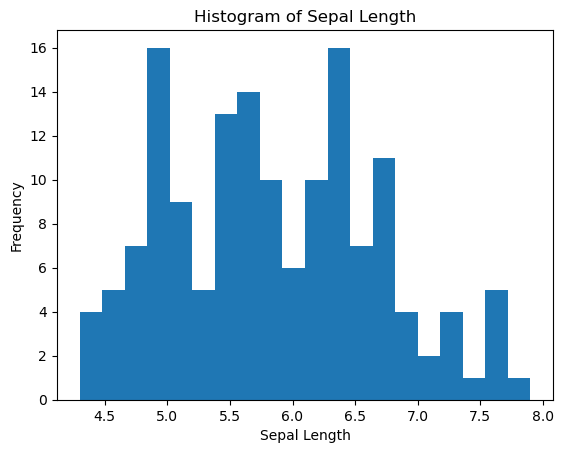

In [14]:
# Plot histogram of sepal length
plt.hist(iris_df['sepal length'], bins=20)
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.title('Histogram of Sepal Length')  
plt.show()

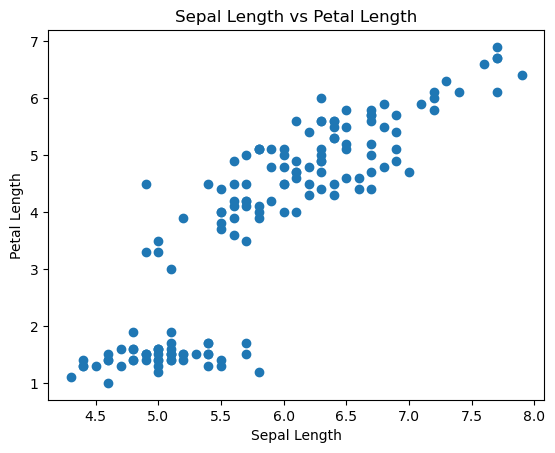

In [ ]:
# Scatter plot of sepal length vs petal length
plt.scatter(iris_df['sepal length'], iris_df['petal length'])
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Sepal Length vs Petal Length')

# Write the plot to a file
plt.savefig('plot.png')

plt.show()

In [10]:
# Plot sepal_length vs sepal_width with color coding based on sepal_length standard deviation
mean_sepal_length = iris_df['sepal length'].mean()
std_sepal_length = iris_df['sepal length'].std()

# Create colors for each point
diff_sepal_length = iris_df['sepal length'] - mean_sepal_length
abs_diff_sepal_length = abs(diff_sepal_length)
colors = ['red' if x > std_sepal_length else 'blue' for x in abs_diff_sepal_length]

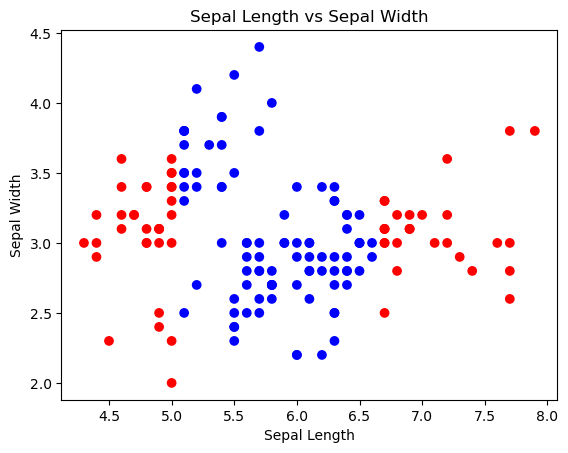

In [40]:
plt.scatter(iris_df['sepal length'], iris_df['sepal width'], c=colors)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Sepal Length vs Sepal Width')

# Write the plot to a file
plt.savefig('plot.png')

plt.show()

['7.9', '4.4', '6.9', '2.5']